In [43]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# Prikaz podataka

In [ ]:

data_set = pd.read_csv("oasis_test_patients_metadata.csv")

print(data_set)

                ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0    OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1    OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2    OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
3    OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
4    OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
..             ...  ..  ...  ...   ...  ...   ...  ...   ...    ...    ...   
239  OAS1_0156_MR2   F    R   20   NaN  NaN   NaN  NaN  1577  0.832  1.113   
240  OAS1_0202_MR2   F    R   23   NaN  NaN   NaN  NaN  1548  0.861  1.134   
241  OAS1_0230_MR2   F    R   19   NaN  NaN   NaN  NaN  1577  0.849  1.113   
242  OAS1_0249_MR2   F    R   28   NaN  NaN   NaN  NaN  1215  0.865  1.444   
243  OAS1_0395_MR2   F    R   26   NaN  NaN   NaN  NaN  1283  0.834  1.368   

     Delay             class  
0      NaN       NonDemented  
1

In [ ]:
print(data_set.info())
print(data_set.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      244 non-null    object 
 1   M/F     244 non-null    object 
 2   Hand    244 non-null    object 
 3   Age     244 non-null    int64  
 4   Educ    121 non-null    float64
 5   SES     116 non-null    float64
 6   MMSE    121 non-null    float64
 7   CDR     121 non-null    float64
 8   eTIV    244 non-null    int64  
 9   nWBV    244 non-null    float64
 10  ASF     244 non-null    float64
 11  Delay   10 non-null     float64
 12  class   244 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 24.9+ KB
None
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2  OAS1_0004_MR1   M    R   28   NaN  NaN   

### Da li imamo null vrednosti

In [ ]:
print(data_set.isnull().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     123
SES      128
MMSE     123
CDR      123
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


In [38]:
missing_counts = data_set.isnull().sum()

missing_percent = (missing_counts / len(data_set)) * 100

for col, pct in missing_percent.items():
    print(f"{col:10} {missing_counts[col]:5} -> ({pct:.1f}%)")

ID             0 -> (0.0%)
M/F            0 -> (0.0%)
Hand           0 -> (0.0%)
Age            0 -> (0.0%)
Educ         123 -> (50.4%)
SES          128 -> (52.5%)
MMSE         123 -> (50.4%)
CDR          123 -> (50.4%)
eTIV           0 -> (0.0%)
nWBV           0 -> (0.0%)
ASF            0 -> (0.0%)
Delay        234 -> (95.9%)
class          0 -> (0.0%)


Da li imamo duplikate

In [37]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Broj duplikata:{duplicates.sum()}")

Empty DataFrame
Columns: [ID, M/F, Hand, Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF, Delay, class]
Index: []
Broj duplikata:0


### Izbacivanje nepotrebnoh polja ID Delay 

ID je samo indentifikator i nije potreban za dalji rad, dok Delay ima previše praznih polja.

In [ ]:
data_set = data_set.drop(['ID', 'Delay'], axis=1)

### Popunjavanje polja koji nemaju vrednosti medianom

In [16]:
for col in ['Educ', 'SES', 'MMSE', 'CDR']:
    data_set[col] = data_set[col].fillna(data_set[col].median())

In [19]:
print(data_set.isnull().sum())

M/F      0
Hand     0
Age      0
Educ     0
SES      0
MMSE     0
CDR      0
eTIV     0
nWBV     0
ASF      0
class    0
dtype: int64


### Label encoding

In [ ]:
le = LabelEncoder()

data_set['M/F'] = le.fit_transform(data_set['M/F'])   
data_set['Hand'] = le.fit_transform(data_set['Hand']) 
data_set['class'] = le.fit_transform(data_set['class']) 

In [24]:
print(data_set.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M/F     244 non-null    int64  
 1   Hand    244 non-null    int64  
 2   Age     244 non-null    int64  
 3   Educ    244 non-null    float64
 4   SES     244 non-null    float64
 5   MMSE    244 non-null    float64
 6   CDR     244 non-null    float64
 7   eTIV    244 non-null    int64  
 8   nWBV    244 non-null    float64
 9   ASF     244 non-null    float64
 10  class   244 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 21.1 KB
None


### Korelaciona matrica

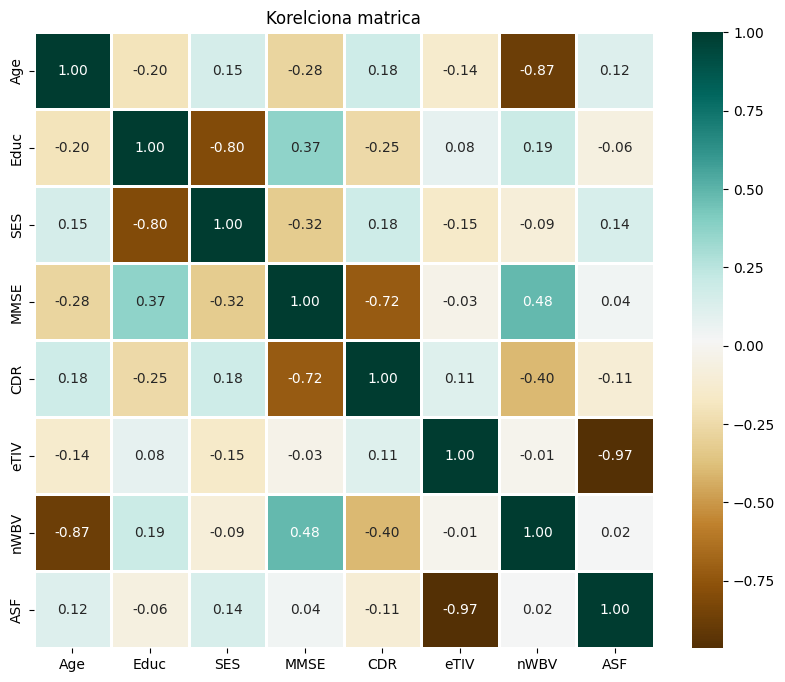

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']
plt.figure(figsize=(10,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='BrBG', linewidths=1)
plt.title("Korelciona matrica")
plt.show()


### Distribucija klasa

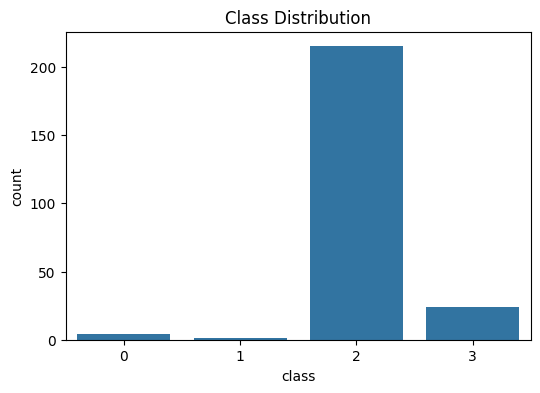

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data_set)
plt.title("Class Distribution")
plt.show()

In [ ]:
X = data_set.drop('class', axis=1)  
y = data_set['class']             

In [ ]:
print(y.value_counts())

class
NonDemented         215
VeryMildDemented     24
MildDemented          4
ModerateDemented      1
Name: count, dtype: int64


Spajamo klase sa malim brojem primeraka

In [32]:
data_set['class'] = data_set['class'].replace({
    'ModerateDemented': 'MildDemented'
})

### Outliers

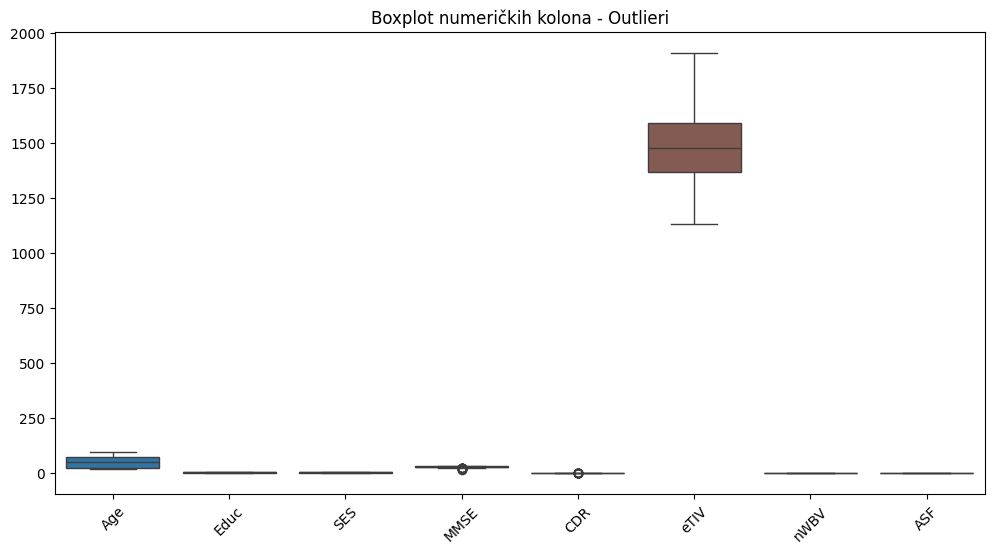

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

plt.figure(figsize=(12,6))
sns.boxplot(data=data_set[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot numeričkih kolona - Outlieri")
plt.show()


Skaliranje

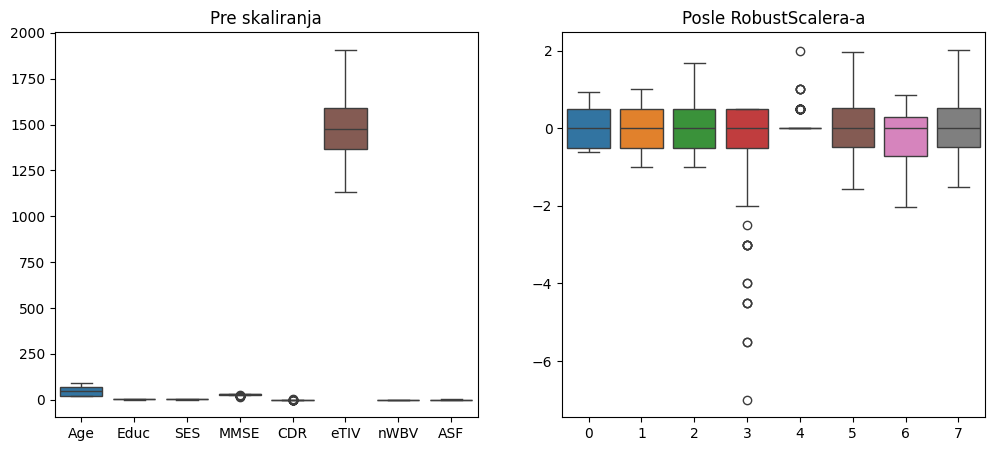

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(data_set[num_cols])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=data_set[num_cols])
plt.title("Pre skaliranja")
plt.subplot(1,2,2)
sns.boxplot(data=X_scaled)
plt.title("Posle RobustScalera-a")
plt.show()


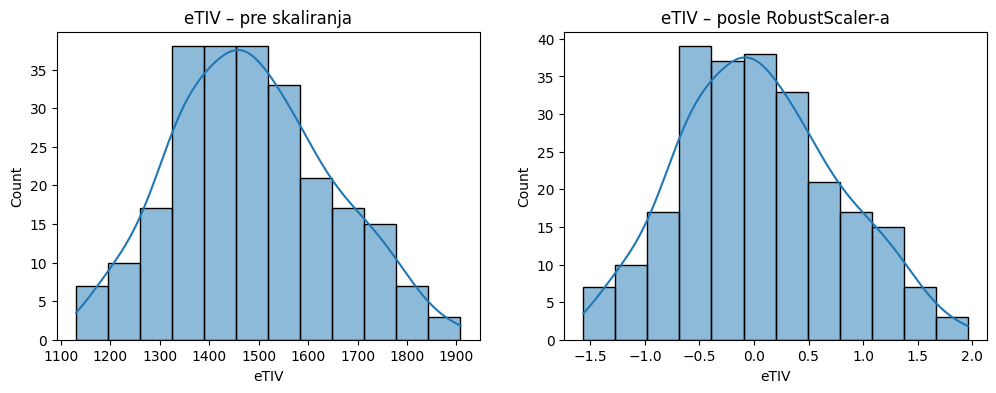

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

col = "eTIV" 

scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(data_set[col], kde=True)
plt.title(f"{col} – pre skaliranja")

plt.subplot(1,2,2)
sns.histplot(scaled_df[col], kde=True)
plt.title(f"{col} – posle RobustScaler-a")

plt.show()


80/20 

In [ ]:
from sklearn.model_selection import train_test_split

X = data_set.drop('class', axis=1)  
y = data_set['class']     


X = X.drop(columns=['ID', 'Delay'])
    
le = LabelEncoder()
for col in ['M/F', 'Hand']:
    X[col] = le.fit_transform(X[col])          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['Educ','SES','MMSE','CDR']  
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())

print("Veličina trening skupa X:", X_train.shape)
print("Veličina test skupa X:", X_test.shape)
print("Veličina trening skupa y:", y_train.shape)
print("Veličina test skupa y:", y_test.shape)

print("\nDistribucija klasa u trening skupu:")
print(y_train.value_counts())

print("\nDistribucija klasa u test skupu:")
print(y_test.value_counts())


Veličina trening skupa X: (195, 10)
Veličina test skupa X: (49, 10)
Veličina trening skupa y: (195,)
Veličina test skupa y: (49,)

Distribucija klasa u trening skupu:
class
NonDemented         172
VeryMildDemented     19
MildDemented          4
Name: count, dtype: int64

Distribucija klasa u test skupu:
class
NonDemented         43
VeryMildDemented     5
MildDemented         1
Name: count, dtype: int64


Balansiranje trening skupa

In [61]:
print(X_train.dtypes)
print("Broj NaN u X_train:")
print(X_train.isna().sum())


M/F       int64
Hand      int64
Age       int64
Educ    float64
SES     float64
MMSE    float64
CDR     float64
eTIV      int64
nWBV    float64
ASF     float64
dtype: object
Broj NaN u X_train:
M/F     0
Hand    0
Age     0
Educ    0
SES     0
MMSE    0
CDR     0
eTIV    0
nWBV    0
ASF     0
dtype: int64


Treniranje modela

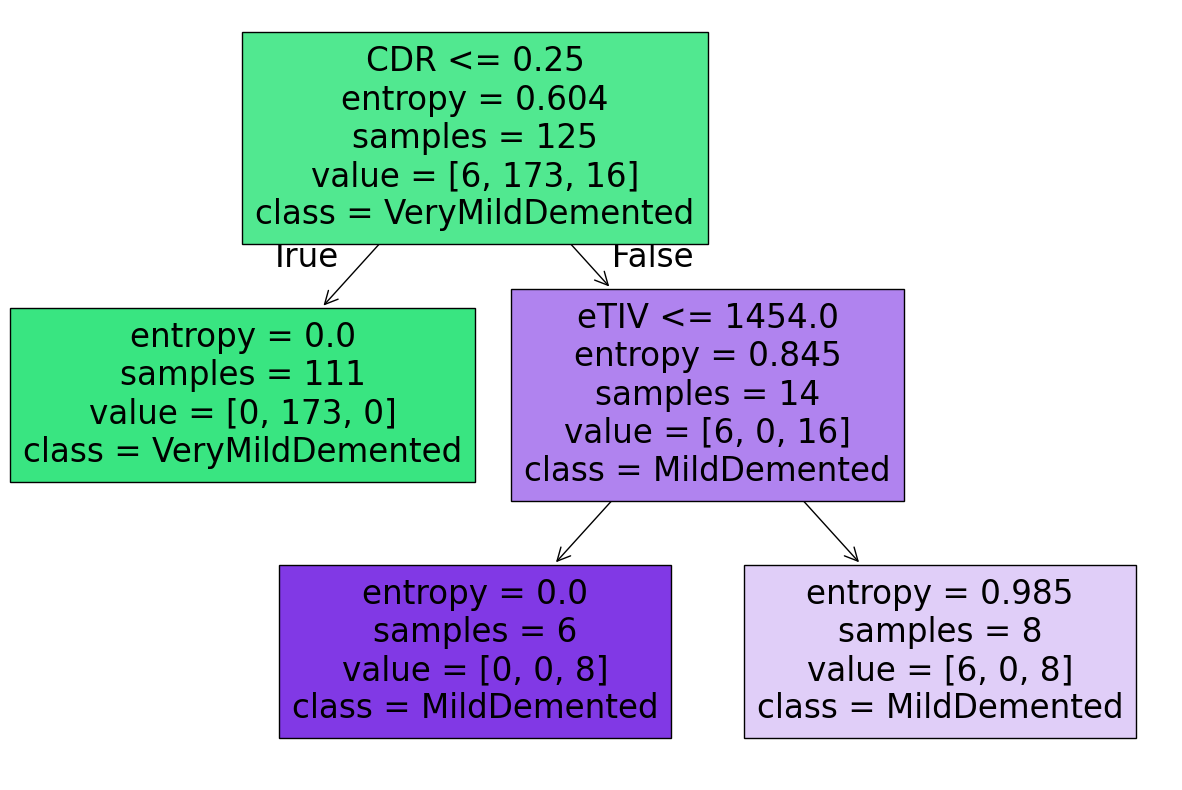

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Random Forest
randClf = RandomForestClassifier(random_state=0, max_depth=2, n_estimators=100, criterion='entropy')
randClf.fit(X_train, y_train)

# Prvo drvo
first_tree = randClf.estimators_[0]

# Pravilne klase
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented']

# Plot
plt.figure(figsize=(15,10))
tree.plot_tree(first_tree, feature_names=X_train.columns, class_names=class_names, filled=True)
plt.show()
